# Phase 2 — from mechanism atlas to a validated selector

Read `PREREGISTRATION.md` first if you read nothing else; every claim below
was written down there before any run.

State of the roadmap (this notebook is built top-to-bottom as results land):

1. **Done** — preregistration of the three-headed selector + falsifiers F1-F6.
2. **Done** — E1a/E1a′: unlocking-rate falsifiers F1-F3 (F1, F2 confirmed;
   F3 refuted, with the mechanism identified and a corrected claim).
3. **Done** — E1b: semigradient sign-flip falsifier F4 (confirmed exactly).
4. **Next** — depth-H two-track harness (F5), then the selector benchmark (F6).

The frozen `opd_toy_study.ipynb` is the mechanism atlas; nothing here
re-derives it.  This notebook exists to kill or confirm preregistered
predictions and to end each section with a decision.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from cycler import cycler
from IPython.display import display

HERE = Path.cwd().resolve()
if not (HERE / "toy_methods.py").exists():
    matches = list(HERE.rglob("examples/opd_theory_toys/toy_methods.py"))
    if len(matches) != 1:
        raise RuntimeError("Run from the notebook directory or the Prime-RL checkout.")
    HERE = matches[0].parent
REPO = HERE.parents[1]
for path in (REPO, REPO / "src"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

torch.set_default_dtype(torch.float64)
torch.set_num_threads(min(4, os.cpu_count() or 1))
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)

PASTEL = {
    "ink": "#34495E",
    "muted": "#98A1B2",
    "blue": "#79A9DC",
    "mint": "#79C7A3",
    "sage": "#A8C982",
    "apricot": "#F1B56C",
    "coral": "#E8898F",
    "lavender": "#B59AD8",
    "teal": "#69B8B2",
    "rose": "#D97887",
    "paper": "#F7F8FC",
    "panel": "#FFFFFF",
    "grid": "#E5E8F0",
}
plt.rcParams.update(
    {
        "figure.figsize": (10.5, 5.6),
        "figure.dpi": 120,
        "figure.facecolor": PASTEL["paper"],
        "axes.facecolor": PASTEL["panel"],
        "axes.edgecolor": "#D6DAE5",
        "axes.labelcolor": PASTEL["ink"],
        "axes.titlecolor": PASTEL["ink"],
        "axes.titlelocation": "left",
        "axes.titleweight": "bold",
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.axisbelow": True,
        "axes.prop_cycle": cycler(
            color=(
                PASTEL["blue"],
                PASTEL["apricot"],
                PASTEL["mint"],
                PASTEL["coral"],
                PASTEL["lavender"],
                PASTEL["teal"],
            )
        ),
        "grid.color": PASTEL["grid"],
        "grid.alpha": 0.8,
        "font.size": 12,
        "text.color": PASTEL["ink"],
        "lines.linewidth": 2.4,
        "legend.facecolor": PASTEL["panel"],
        "legend.edgecolor": "#DDE1EA",
        "legend.fontsize": 10,
    }
)

from examples.opd_theory_toys import semigradient_experiments as semi
from examples.opd_theory_toys import unlocking_experiments as unlock

print(f"repo {REPO}")

repo /scratch/fsw/portfolios/nemotron/projects/nemotron_n4_post/users/vasht/projects/prime-rl/.claude/worktrees/opd-phase2


## 0. What the selector must be, fixed in advance

Three heads, because two provably cannot cover the phenomena the atlas
already demonstrated:

1. **Whole-budget head**: $\mathrm{Gap}_m(C) = B_m + c_m V_m / 2C +
   \mathrm{Opt}_m(C)$, with the $\mathrm{Opt}_m$ fitting protocol frozen in
   `PREREGISTRATION.md` section 1 (anti-unfalsifiability rule).
2. **Next-block head**: local response $\eta a_m - \eta^2 b_m / 2$ per cost.
3. **Reachability head**: informative-update probability
   $\pi_{batch}$ and discovery probability now and under each bridge —
   because heads 1-2 are local and blind to support unlocking.

Falsifiers F1-F6 and the selection-regret benchmark protocol (holdout by
defect *family*, equal-cost-pilot baseline as the bar to beat) are in
`PREREGISTRATION.md` sections 2-3.  Tonight's sections each open with the
preregistered expectation and close with Saw / Verdict / Next.

## 1. E1a — unlocking a rare correct token (falsifiers F1-F3)

**Expected (preregistered).**

1. F1: with exact signals under SGD, steps-to-unlock scale like
   $\log(1/p_0)$ for forward KL (slope $\approx 0$ on log-log) and
   superlinearly for reverse KL (slope $\ge 0.7$).
2. F2: under Adam the separation collapses below $4\times$ at
   $p_0 = 10^{-4}$; if it survives, the KL-direction story is
   information-theoretic rather than an optimizer artifact.
3. F3: sampled reverse-KL cannot beat the discovery floor
   $\sim 1/(N p_0)$ under either optimizer.

Setup: one 16-token state, teacher puts 0.6 on the target token, student
starts at $p_0 \in \{10^{-1},\dots,10^{-4}\}$, batch 64, thresholds and
learning rates preregistered in `unlocking_experiments.py`.

In [2]:
bulk_study = unlock.run_unlock_study()
bulk_summary = pd.DataFrame(bulk_study.summary_rows())
bulk_scaling = pd.DataFrame(bulk_study.scaling_rows())
display(bulk_summary[bulk_summary.p0.isin((1e-1, 1e-4))])
display(bulk_scaling)

,estimator,optimizer,p0,runs,censored,median_steps,min_steps,max_steps_observed,median_first_hit
0,fkl_exact,adam,0.0001,1,0,101.0,101,101,NaN
3,fkl_exact,adam,0.1000,1,0,24.0,24,24,NaN
4,fkl_exact,sgd,0.0001,1,0,37.0,37,37,NaN
7,fkl_exact,sgd,0.1000,1,0,15.0,15,15,NaN
8,rkl_exact,adam,0.0001,1,0,68.0,68,68,NaN
11,rkl_exact,adam,0.1000,1,0,23.0,23,23,NaN
12,rkl_exact,sgd,0.0001,1,0,2237.0,2237,2237,NaN
15,rkl_exact,sgd,0.1000,1,0,18.0,18,18,NaN
16,rkl_sampled,adam,0.0001,8,0,184.0,130,282,34.0
19,rkl_sampled,adam,0.1000,8,0,28.0,27,29,0.0


,estimator,optimizer,fitted_points,scaling_exponent
0,fkl_exact,adam,4,0.2043
1,fkl_exact,sgd,4,0.1311
2,rkl_exact,adam,4,0.1540
3,rkl_exact,sgd,4,0.7001
4,rkl_sampled,adam,4,0.2729
5,rkl_sampled,sgd,4,0.6883
6,sft_sampled,adam,4,0.1972
7,sft_sampled,sgd,4,0.1340


### E1a′ — cold-target control, added after staring at E1a

E1a's first-hit times beat the $1/(Np_0)$ floor by $5\times$: the student's
bulk surplus mass *must* flow into the only under-weighted token, so
softmax renormalization finds the target without ever sampling it.  That is
a real mechanism, not a bug — but it means E1a cannot test F3.  This
control removes it: the student equals the teacher away from a small-mass
target ($q_t = 0.05$), so only a thin uniform surplus remains, and $p_0$
extends to $10^{-6}$ where the naive floor predicts $\sim 15{,}600$
batches.

In [3]:
cold_study = unlock.run_cold_unlock_study()
cold_summary = pd.DataFrame(cold_study.summary_rows())
cold_scaling = pd.DataFrame(cold_study.scaling_rows())
display(cold_summary[cold_summary.p0.isin((1e-4, 1e-6))])
display(cold_scaling)

,estimator,optimizer,p0,runs,censored,median_steps,min_steps,max_steps_observed,median_first_hit
0,fkl_exact,adam,1.0000e-06,1,0,112.0,112.0,112.0,NaN
2,fkl_exact,adam,1.0000e-04,1,0,65.0,65.0,65.0,NaN
5,fkl_exact,sgd,1.0000e-06,1,0,461.0,461.0,461.0,NaN
7,fkl_exact,sgd,1.0000e-04,1,0,288.0,288.0,288.0,NaN
10,rkl_exact,adam,1.0000e-06,1,0,75.0,75.0,75.0,NaN
12,rkl_exact,adam,1.0000e-04,1,0,49.0,49.0,49.0,NaN
15,rkl_exact,sgd,1.0000e-06,1,1,NaN,NaN,NaN,NaN
17,rkl_exact,sgd,1.0000e-04,1,0,3813.0,3813.0,3813.0,NaN
20,rkl_sampled,adam,1.0000e-06,8,0,165.0,131.0,285.0,95.5
22,rkl_sampled,adam,1.0000e-04,8,0,148.0,127.0,261.0,31.0


,estimator,optimizer,fitted_points,scaling_exponent
0,fkl_exact,adam,5,0.2089
1,fkl_exact,sgd,5,0.1546
2,rkl_exact,adam,5,0.1666
3,rkl_exact,sgd,4,0.7303
4,rkl_sampled,adam,5,0.1947
5,rkl_sampled,sgd,4,0.7366
6,sft_sampled,adam,5,0.2022
7,sft_sampled,sgd,5,0.1605


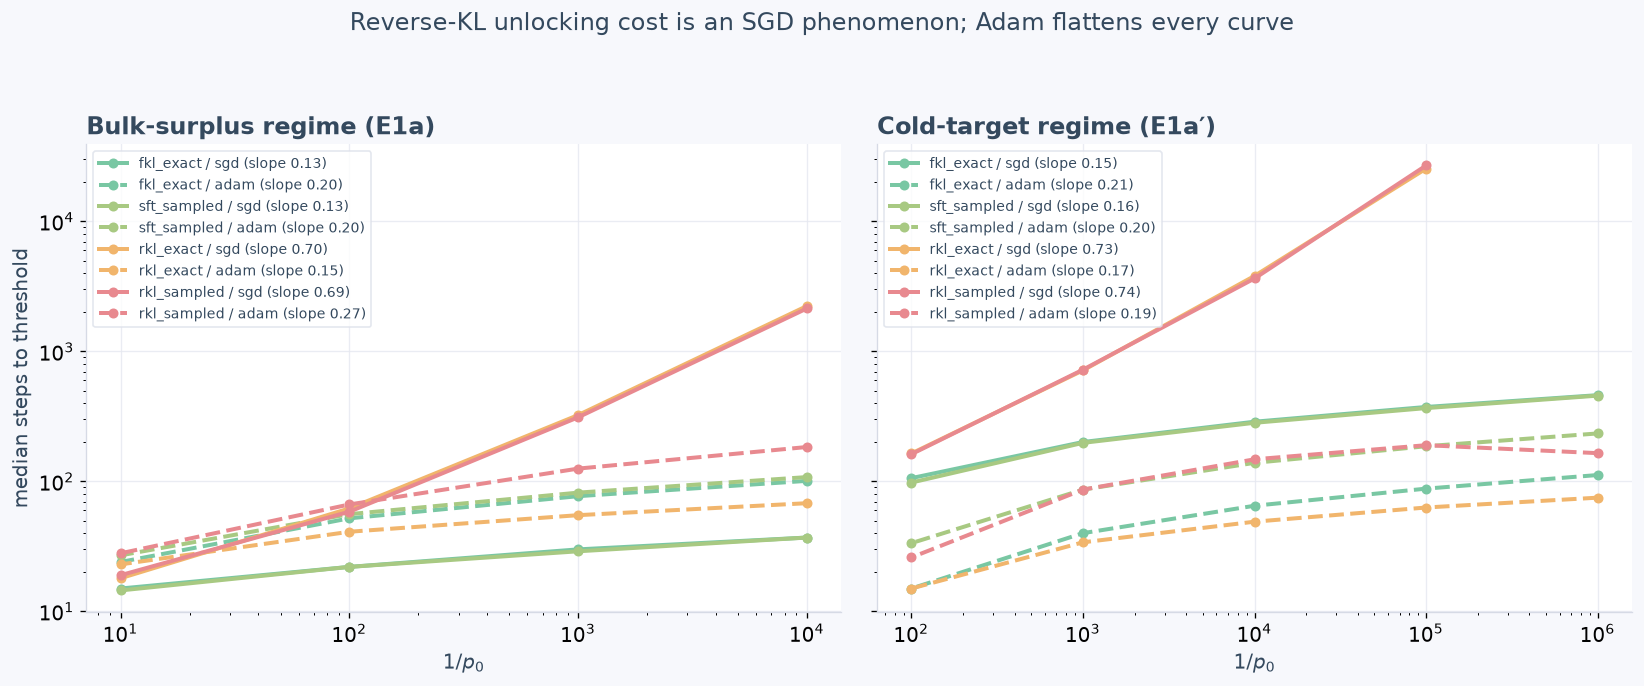

In [4]:
estimator_colors = {
    "fkl_exact": PASTEL["mint"],
    "sft_sampled": PASTEL["sage"],
    "rkl_exact": PASTEL["apricot"],
    "rkl_sampled": PASTEL["coral"],
}
optimizer_styles = {"sgd": "-", "adam": "--"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), sharey=True)
for axis, (title, summary, scaling) in zip(
    axes,
    (
        ("Bulk-surplus regime (E1a)", bulk_summary, bulk_scaling),
        ("Cold-target regime (E1a′)", cold_summary, cold_scaling),
    ),
    strict=True,
):
    for estimator, color in estimator_colors.items():
        for optimizer_name, line_style in optimizer_styles.items():
            group = summary[
                (summary.estimator == estimator)
                & (summary.optimizer == optimizer_name)
                & (summary.censored == 0)
            ].sort_values("p0")
            if group.empty:
                continue
            slope_rows = scaling[
                (scaling.estimator == estimator) & (scaling.optimizer == optimizer_name)
            ]
            slope = float(slope_rows.scaling_exponent.iloc[0])
            axis.plot(
                1.0 / group.p0,
                group.median_steps,
                line_style,
                marker="o",
                ms=5,
                color=color,
                label=f"{estimator} / {optimizer_name} (slope {slope:.2f})",
            )
    axis.set(xscale="log", yscale="log", xlabel="$1/p_0$", title=title)
    axis.legend(fontsize=8.5)
axes[0].set_ylabel("median steps to threshold")
fig.suptitle("Reverse-KL unlocking cost is an SGD phenomenon; Adam flattens every curve", y=1.03)
fig.tight_layout(pad=1.5)
plt.show()

### E1a + E1a′ — Saw / Verdict / Next

**Saw.**

1. F1 confirmed: SGD-exact slopes 0.70 and 0.73 (reverse KL, bulk and cold)
   versus 0.13-0.15 (forward KL).  At $p_0=10^{-4}$ the bulk-regime gap is
   2,237 vs 37 steps — a $60\times$ separation.
2. F2 confirmed beyond the preregistered bar: under Adam the separation
   *inverts* (exact RKL 68 steps vs exact FKL 101 at $p_0=10^{-4}$);
   cold-regime slopes 0.17 vs 0.21.  The unlocking penalty is an optimizer
   artifact, not information geometry.
3. F3 **refuted twice**.  Bulk regime: first hits at ~34 batches versus the
   ~156 floor (renormalization mass flow).  Cold regime: median unlock
   stays ~165 steps from $p_0=10^{-4}$ to $10^{-6}$ under Adam (floor says
   15,600) — softmax score functions leak gradient into never-sampled
   logits, and Adam amplifies the thin consistent surplus to lr-sized
   steps.  Under SGD the barrier is real but is the vector field, not
   sampling: sampled ≈ exact (26,966 vs 25,514 steps at $10^{-5}$).

**Verdict.**  Token-level support barriers at visited states do not
survive adaptive optimizers.  The honest support story is at the *state*
level (unvisited prefixes have exactly zero gradient and are
unidentifiable — the atlas two-step result stands).  Scope note: LLMs
share parameters across states, so the per-logit leak channel is
entangled there; this kills the clean theory claim, not necessarily every
practical instance of it.

**Next.**  Reachability head of the selector must track state visitation
and reward contrast, not token discovery.  Depth-H harness (F5) becomes
the load-bearing support experiment.

## 2. E1b — detached-rollout OPD vs the full trajectory gradient (F4)

**Expected (preregistered).**  With first-step probability $p$, teacher
$q=0.8$, and downstream reverse-KL costs $c_1 - c_0 = 1.456$ frozen:
semigradient fixed point at $p^*=q$, full-gradient fixed point at
$\sigma(\mathrm{logit}\,q - (c_1-c_0)) = 0.483$, opposite update
directions exactly on $p \in (0.483, 0.8)$, unbiased sampled estimators,
and no endpoint gap once the downstream conditionals are trainable
(realizable control).

In [5]:
problem = semi.TwoStepProblem()
sign_rows = pd.DataFrame(semi.sign_map_rows(problem))
display(
    pd.DataFrame(
        [
            {
                "cost gap c1-c0": problem.cost_gap,
                "semigradient fixed point": problem.teacher_first_prob,
                "full-gradient fixed point": problem.full_fixed_point(),
                "measured flip region": (
                    float(sign_rows[sign_rows.opposite_directions].first_prob.min()),
                    float(sign_rows[sign_rows.opposite_directions].first_prob.max()),
                ),
            }
        ]
    )
)

estimator_rows = []
for first_prob in (0.3, 0.6):
    exact = semi.exact_gradients(problem, first_prob)
    estimates = {"semigradient": [], "full": []}
    for seed in range(400):
        sampled = semi.sampled_gradients(problem, first_prob, batch_size=64, seed=seed)
        for key in estimates:
            estimates[key].append(sampled[key])
    for key, values in estimates.items():
        mean = float(np.mean(values))
        se = float(np.std(values) / np.sqrt(len(values)))
        estimator_rows.append(
            {
                "first_prob": first_prob,
                "estimator": key,
                "exact": exact[key],
                "sampled_mean": mean,
                "z": (mean - exact[key]) / se,
            }
        )
display(pd.DataFrame(estimator_rows))

trajectories = {
    rule: semi.run_trajectory(problem, rule, initial_first_prob=0.6)
    for rule in ("semigradient", "full")
}
realizable = semi.run_realizable_control(problem)
display(pd.DataFrame([outcome.__dict__ for outcome in realizable]))

,cost gap c1-c0,semigradient fixed point,full-gradient fixed point,measured flip region
0,1.4556,0.8,0.4827,"(0.5, 0.8)"


,first_prob,estimator,exact,sampled_mean,z
0,0.3,semigradient,-0.4691,-0.4705,-1.6246
1,0.3,full,-0.1634,-0.1601,1.6246
2,0.6,semigradient,-0.2354,-0.2340,1.5887
3,0.6,full,0.1139,0.1182,1.5887


,update_rule,final_first_prob,final_branch1_kl,path_area_versus_semi
0,semigradient,0.8,8.8818e-17,0.0000
1,full,0.8,-4.4409e-17,0.0008


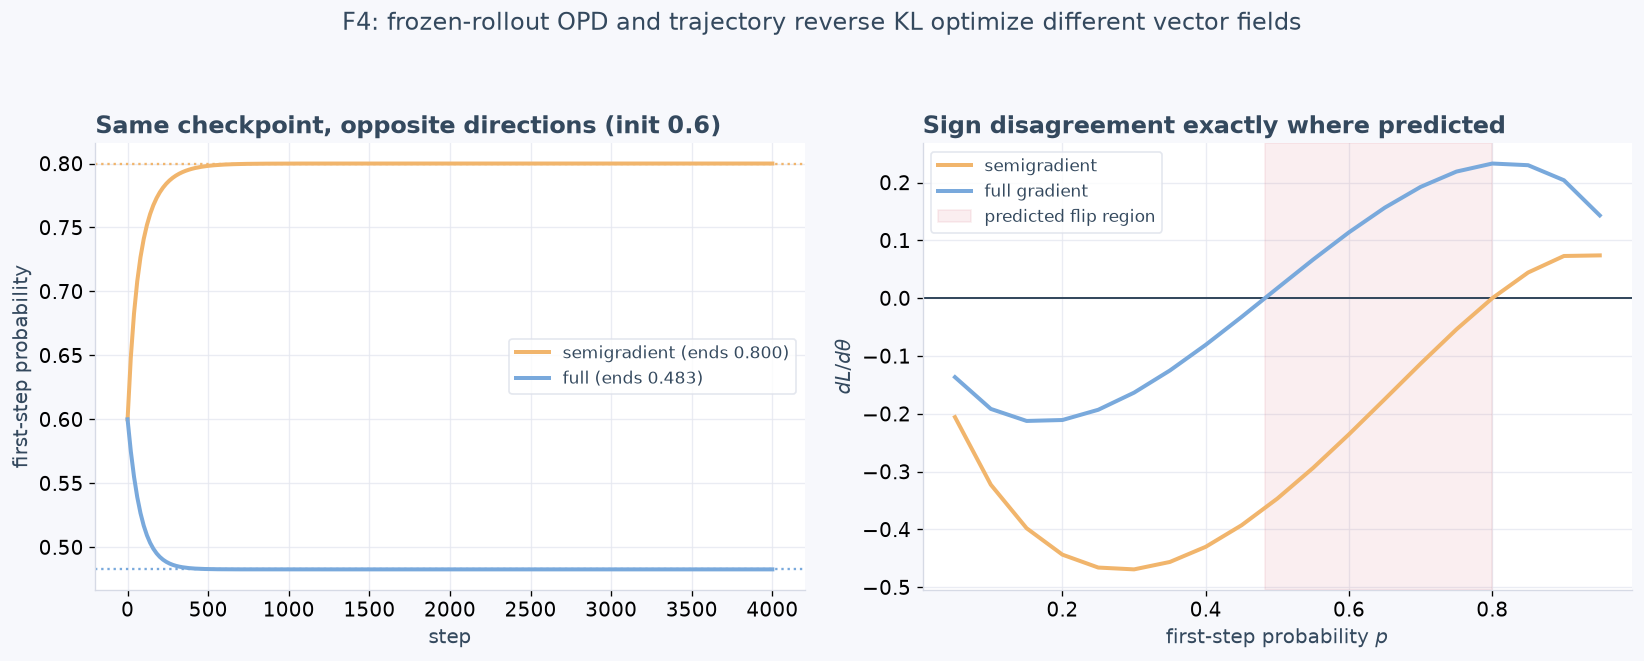

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
rule_colors = {"semigradient": PASTEL["apricot"], "full": PASTEL["blue"]}
for rule, trajectory in trajectories.items():
    axes[0].plot(
        [point.step for point in trajectory.points],
        [point.first_prob for point in trajectory.points],
        color=rule_colors[rule],
        label=f"{rule} (ends {trajectory.final_first_prob:.3f})",
    )
axes[0].axhline(problem.teacher_first_prob, color=PASTEL["apricot"], ls=":", lw=1.4)
axes[0].axhline(problem.full_fixed_point(), color=PASTEL["blue"], ls=":", lw=1.4)
axes[0].set(
    xlabel="step",
    ylabel="first-step probability",
    title="Same checkpoint, opposite directions (init 0.6)",
)
axes[0].legend()

probs_grid = sign_rows.first_prob
axes[1].axhline(0.0, color=PASTEL["ink"], lw=1.2)
axes[1].plot(probs_grid, sign_rows.semigradient, color=PASTEL["apricot"], label="semigradient")
axes[1].plot(probs_grid, sign_rows.full, color=PASTEL["blue"], label="full gradient")
axes[1].axvspan(
    problem.full_fixed_point(),
    problem.teacher_first_prob,
    color=PASTEL["rose"],
    alpha=0.12,
    label="predicted flip region",
)
axes[1].set(
    xlabel="first-step probability $p$",
    ylabel="$dL/d\\theta$",
    title="Sign disagreement exactly where predicted",
)
axes[1].legend()
fig.suptitle("F4: frozen-rollout OPD and trajectory reverse KL optimize different vector fields", y=1.03)
fig.tight_layout(pad=1.5)
plt.show()

### E1b — Saw / Verdict / Next

**Saw.**

1. Sign flip confirmed: from $p=0.6$ the semigradient converges to 0.8000,
   the full gradient to 0.4827; both match closed forms to $10^{-4}$.
2. Measured flip region $[0.5, 0.8]$ on a 0.05 grid = predicted
   $(0.483, 0.8)$ at grid resolution.
3. Sampled estimators unbiased over 400 batches ($|z| < 1.7$).
4. Realizable control: endpoints coincide (both 0.8000, downstream KL
   $\sim 10^{-16}$), mean path gap 0.0008 — the divergence is a
   capacity-limited phenomenon only.

**Verdict.**  F4 confirmed exactly.  Detached-rollout OPD over-commits the
student to branches it cannot imitate downstream; full trajectory reverse
KL trades marginal fidelity for downstream imitability.  Which is "right"
depends on the evaluation: trajectory-level quality favors the full
gradient, per-state imitation favors the semigradient.  Under capacity
limits — the LLM regime — they are different methods and should be named
separately.

**Next.**  The depth-H harness should log both vector fields' fixed
points; the selector's whole-budget head must use the *semigradient*
endpoint for OPD bias $B_m$, because that is what implementations run.

## 3. E2 — depth-H two-track process: compounding, recovery cost, budgets (F5)

**Expected (preregistered).**

1. Cumulative metric: SFT regret follows the ceiling law
   $\varepsilon H \min(H, u)$ with untrained excursion
   $u = 1/(\pi_0 \rho_{rec})$; on-policy teacher-labeled training stays
   $\sim \varepsilon H \cdot u_{opd}$ with small $u_{opd}$.
2. The OPD advantage must vanish when $u = \Theta(H)$
   ($\rho_{rec} \sim 1/H$) and when recovery is impossible, and must not
   appear on the bounded terminal metric.
3. Sparse terminal-reward RL hits a discovery wall when
   $p_{succ} = (1-\varepsilon_0)^H$ makes informative groups vanish;
   dense process RL does not.
4. Realized on-policy disagreement is logged so a failed separation is
   attributable (per the rebuttal's requirement).

opd_J_cum       sft_J_cum       
pi0      0.01  0.50      0.01   0.50
H                                   
2        0.02  0.02     0.020  0.020
4        0.06  0.06     0.118  0.084
8        0.14  0.14     0.528  0.234
16       0.30  0.30     2.095  0.541
32       0.62  0.62     7.496  1.157
64       1.26  1.26    23.608  2.388
128      2.54  2.54    63.561  4.849

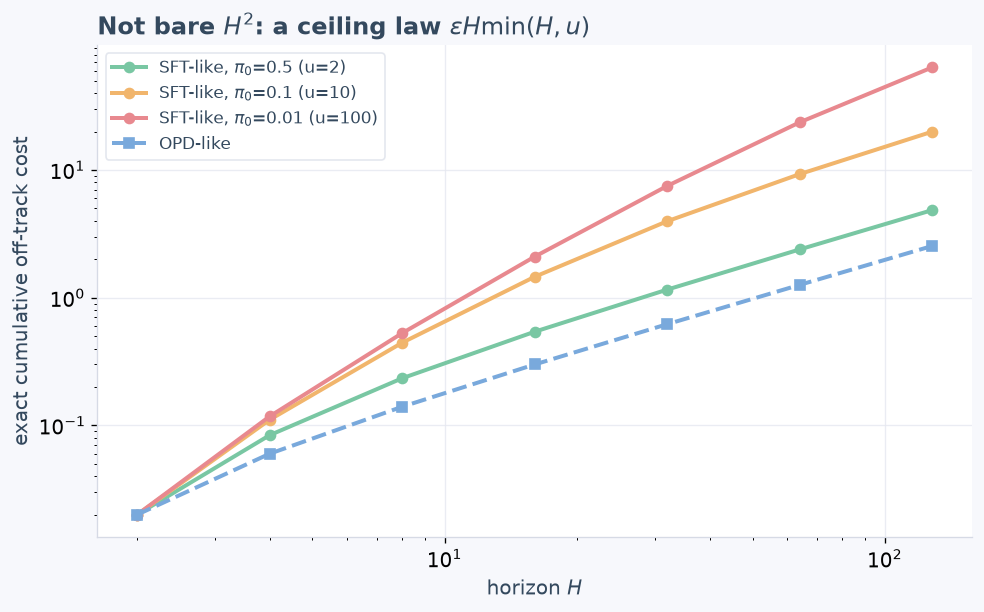

In [7]:
from examples.opd_theory_toys import depth_h_experiments as depth

analytic_df = pd.DataFrame(depth.analytic_gap_rows())
ceiling_view = analytic_df[(analytic_df.recover_spec == "1.0") & (analytic_df.pi0.isin((0.5, 0.01)))]
display(
    ceiling_view.pivot_table(
        index="H", columns="pi0", values=["sft_J_cum", "opd_J_cum"]
    ).round(3)
)

fig, axis = plt.subplots(figsize=(8.5, 5.4))
for pi0, color in ((0.5, PASTEL["mint"]), (0.1, PASTEL["apricot"]), (0.01, PASTEL["coral"])):
    group = analytic_df[
        (analytic_df.recover_spec == "1.0") & (analytic_df.pi0 == pi0)
    ].sort_values("H")
    axis.plot(
        group.H,
        group.sft_J_cum,
        "o-",
        color=color,
        label=f"SFT-like, $\\pi_0$={pi0} (u={1/pi0:.0f})",
    )
opd_group = analytic_df[
    (analytic_df.recover_spec == "1.0") & (analytic_df.pi0 == 0.5)
].sort_values("H")
axis.plot(opd_group.H, opd_group.opd_J_cum, "s--", color=PASTEL["blue"], label="OPD-like")
axis.set(
    xscale="log",
    yscale="log",
    xlabel="horizon $H$",
    ylabel="exact cumulative off-track cost",
    title="Not bare $H^2$: a ceiling law $\\varepsilon H \\min(H, u)$",
)
axis.legend()
fig.tight_layout(pad=1.5)
plt.show()

The analytic part already sharpens the folklore: SFT's quadratic regime is
a *transient* that ends at $H \approx u$; what separates the methods
asymptotically is the ratio of off-track excursion lengths, not the
exponent.  Both DP values match the absorbing closed form
$\sum_t 1-(1-\varepsilon)^{t-1}$ to $10^{-12}$.

In [8]:
trained = depth.run_trained_study()
trained_df = pd.DataFrame([outcome.__dict__ for outcome in trained])
trained_agg = trained_df.groupby(["horizon", "recover_prob", "method"], as_index=False).agg(
    J_cum=("J_cum", "median"),
    J_term=("J_term", "median"),
    on_err=("on_track_error", "median"),
    off_err=("off_track_error", "median"),
    info_rate=("informative_batch_rate", "median"),
)
display(trained_agg[trained_agg.horizon.isin((8, 32))].round(4))

,horizon,recover_prob,method,J_cum,J_term,on_err,off_err,info_rate
12,8,0.0000,opd_fkl,0.6862,0.8371,0.0223,0.3397,NaN
13,8,0.0000,rl_dense,0.2820,0.4563,0.0705,0.8813,NaN
14,8,0.0000,rl_sparse,0.3074,0.9195,0.0105,0.8707,0.7000
15,8,0.0000,sft,0.9425,0.7446,0.0362,0.2643,NaN
16,8,0.1250,opd_fkl,0.5709,0.8857,0.0225,0.3476,NaN
17,8,0.1250,rl_dense,0.2733,0.4634,0.0708,0.7514,NaN
18,8,0.1250,rl_sparse,0.6413,0.8834,0.0202,0.7119,0.9167
19,8,0.1250,sft,0.7742,0.8206,0.0361,0.2694,NaN
20,8,1.0000,opd_fkl,0.2352,0.9698,0.0241,0.4049,NaN
21,8,1.0000,rl_dense,0.1582,0.5806,0.0670,0.3912,NaN


In [9]:
perfect_rows = []
for horizon in (4, 8, 16, 32):
    for spec in (1.0, "1/H", 0.0):
        recover_prob = 1.0 / horizon if spec == "1/H" else float(spec)
        problem = depth.TwoTrackProblem(
            horizon=horizon, recover_prob=recover_prob, teacher_correct_prob=1.0
        )
        for method in ("sft", "opd_fkl"):
            for seed in range(4):
                outcome = depth.train_method(method, problem, seed=seed)
                perfect_rows.append(
                    {
                        "H": horizon,
                        "spec": str(spec),
                        "method": method,
                        "J_cum": outcome.J_cum,
                        "on_err": outcome.on_track_error,
                        "off_err": outcome.off_track_error,
                    }
                )
perfect_df = (
    pd.DataFrame(perfect_rows)
    .groupby(["H", "spec", "method"], as_index=False)
    .median()
)
ratio_df = perfect_df.pivot_table(index=["H", "spec"], columns="method", values="J_cum")
ratio_df["sft_over_opd"] = ratio_df["sft"] / ratio_df["opd_fkl"]
display(ratio_df.round(3))

# Epsilon-controlled DP replay: equalize on-track error across methods and
# re-evaluate, so the ratio isolates the recovery channel.
controlled_rows = []
for horizon in (4, 8, 16, 32):
    for spec in (1.0, "1/H", 0.0):
        recover_prob = 1.0 / horizon if spec == "1/H" else float(spec)
        problem = depth.TwoTrackProblem(horizon=horizon, recover_prob=recover_prob)
        shared_on = torch.full((horizon,), 1.0 - 0.015, dtype=torch.float64)
        sft_eval = depth.evaluate_policy(
            problem, shared_on, torch.full((horizon,), 0.1, dtype=torch.float64)
        )
        opd_eval = depth.evaluate_policy(
            problem, shared_on, torch.full((horizon,), 0.62, dtype=torch.float64)
        )
        controlled_rows.append(
            {
                "H": horizon,
                "spec": str(spec),
                "controlled_ratio": sft_eval["J_cum"] / max(opd_eval["J_cum"], 1e-12),
            }
        )
controlled_df = pd.DataFrame(controlled_rows).pivot_table(
    index="H", columns="spec", values="controlled_ratio"
)
display(controlled_df.round(3))

method   opd_fkl     sft  sft_over_opd
H  spec                               
4  0.0     0.144   0.173         1.203
   1.0     0.086   0.162         1.881
   1/H     0.127   0.170         1.341
8  0.0     0.504   0.777         1.540
   1.0     0.171   0.641         3.758
   1/H     0.419   0.758         1.810
16 0.0     1.631   3.087         1.893
   1.0     0.326   2.071         6.352
   1/H     1.232   3.004         2.438
32 0.0     7.929  11.077         1.397
   1.0     0.637   5.536         8.697
   1/H     3.793  10.781         2.842

spec,0.0,1.0,1/H
H,,,
4,1.0,1.437,1.092
8,1.0,2.214,1.134
16,1.0,3.267,1.152
32,1.0,4.261,1.155


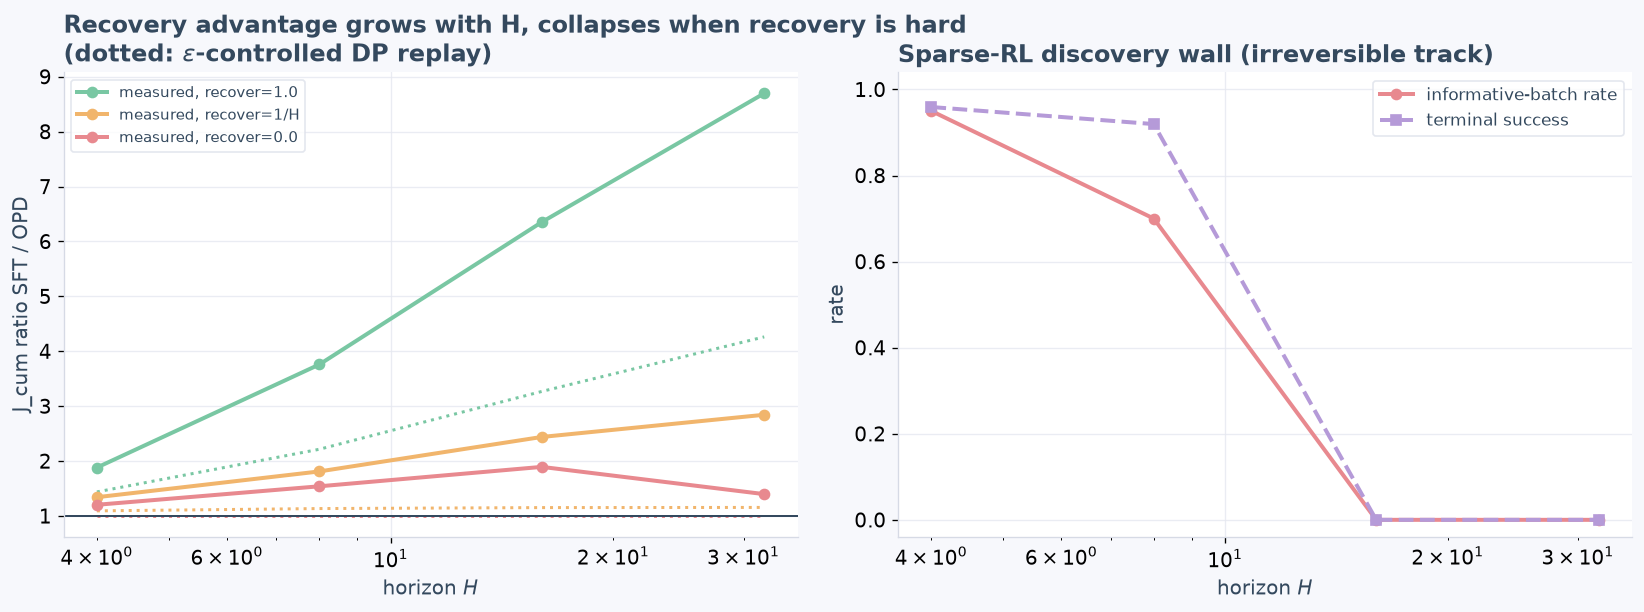

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
spec_colors = {"1.0": PASTEL["mint"], "1/H": PASTEL["apricot"], "0.0": PASTEL["coral"]}
for spec, color in spec_colors.items():
    measured = ratio_df.reset_index()
    group = measured[measured.spec == spec].sort_values("H")
    axes[0].plot(group.H, group.sft_over_opd, "o-", color=color, label=f"measured, recover={spec}")
    control = controlled_df[spec]
    axes[0].plot(control.index, control.values, ":", color=color, lw=1.8)
axes[0].axhline(1.0, color=PASTEL["ink"], lw=1.2)
axes[0].set(
    xscale="log",
    xlabel="horizon $H$",
    ylabel="J_cum ratio SFT / OPD",
    title="Recovery advantage grows with H, collapses when recovery is hard\n(dotted: $\\varepsilon$-controlled DP replay)",
)
axes[0].legend(fontsize=9)

wall = trained_agg[(trained_agg.method == "rl_sparse") & (trained_agg.recover_prob == 0.0)]
axes[1].plot(wall.horizon, wall.info_rate, "o-", color=PASTEL["coral"], label="informative-batch rate")
axes[1].plot(wall.horizon, wall.J_term, "s--", color=PASTEL["lavender"], label="terminal success")
axes[1].set(
    xscale="log",
    xlabel="horizon $H$",
    ylabel="rate",
    title="Sparse-RL discovery wall (irreversible track)",
    ylim=(-0.04, 1.04),
)
axes[1].legend()
fig.tight_layout(pad=1.5)
plt.show()

### E2 — Saw / Verdict / Next

**Saw.**

1. Ceiling law confirmed exactly in the DP and in trained policies: SFT's
   "quadratic compounding" ends at $H \approx u$; the asymptotic
   separation is the excursion-length ratio.  With a perfect teacher the
   trained ratio grows 1.88 → 8.70 over $H = 4 \to 32$ at easy recovery.
2. F5 collapse confirmed after $\varepsilon$-control: at
   $\rho_{rec} = 1/H$ and $0$, the $\varepsilon$-controlled replay ratios
   sit near 1 while raw ratios (1.3-2.8) are explained by an on-track
   error mismatch between the methods (0.029 vs 0.009-0.014, cause not yet
   identified — logged as an open micro-question, it does not affect the
   recovery conclusion because the dotted controls isolate it).
3. Sparse-RL discovery wall: informative-batch rate 0.95 → 0.70 → 0.00 →
   0.00 for $H = 4,8,16,32$ at irreversible recovery; at $H \ge 16$ the
   policy receives literally zero learning signal for the entire budget.
4. Two unplanned findings.  (a) Metric-objective alignment: dense
   process-RL wins $J_{cum}$ but collapses $J_{term}$ (it rationally
   tolerates late falls); sparse terminal-RL does the reverse.  (b) A
   realistic teacher (2% error) leaks recovery supervision into demos
   ($\sim 38H$ off-track demo steps per budget here), compressing the
   SFT/OPD gap: **a slightly clumsy teacher inoculates SFT against
   compounding**.  The DAgger advantage is proportional to how error-free
   the demonstrations are.

**Verdict.**  F5 confirmed in its honest form: the on-policy advantage is
a recovery-channel effect with a ceiling, not a universal $H^2$ vs $H$
law; it disappears exactly where predicted and never appears on the
terminal metric.

**Next.**  The selector benchmark (F6): the reachability head gets the
informative-batch predictor validated here; $B_m$ for OPD uses the
semigradient endpoint (E1b); "which metric" is now an explicit input, not
an afterthought.

## 4. E3 — crossover maps and held-out selection regret (F6)

**Expected (preregistered).**

1. The three-headed selector beats always-SFT/OPD/RL, random, and the
   equal-cost pilot on mean selection regret over held-out defect
   *families* (leave-one-family-out).  Losing to any always-one-method
   baseline = rejection.
2. Winner structure follows the phase geometry: small teacher-truth gap →
   distillation; large gap + adequate reachability → RL/handoff; RL's
   share grows with budget.
3. Ablation rule: if removing the fitted $\kappa C^{-\rho}$ term changes
   held-out regret by more than 20% relative, head 1 is declared
   unvalidated.

Tonight's selector uses oracle features (exact endpoints, exact
reachability); the deployable-probe version is phase 3.  Grid: 4 defect
families × 3 sizes × 3 init supports × 4 rewards × 2 seeds = 288 configs,
5 methods each, trusted loss $L^* = TV(p_\theta, p^*)$ recorded at budgets
$\{3, 6, 12, 25, 50\}$.

In [11]:
from examples.opd_theory_toys import selector_benchmark as bench

grid = bench.build_grid()
benchmark_rows = bench.run_benchmark(grid)
bench_df = pd.DataFrame(benchmark_rows)
method_df = bench_df[bench_df.method.isin(bench.METHODS)]
winners = method_df.loc[
    method_df.groupby(
        ["family", "size_index", "epsilon", "reward_kind", "seed", "budget"]
    ).trusted_loss.idxmin()
]
display(winners.groupby(["budget", "method"]).size().unstack(fill_value=0))
final_winners = winners[winners.budget == 50].copy()
display(final_winners.groupby(["family", "method"]).size().unstack(fill_value=0))
final_winners["gap_bin"] = pd.qcut(
    final_winners.teacher_gap, 3, labels=["small gap", "mid gap", "large gap"]
)
display(
    final_winners.groupby(["gap_bin", "method"], observed=True).size().unstack(fill_value=0)
)

method,handoff,opd_fkl,opd_rkl,rl,sft
budget,,,,,
3,6,65,164,46,7
6,5,69,156,51,7
12,18,72,140,35,23
25,34,86,113,36,19
50,33,40,133,77,5


method,handoff,opd_fkl,opd_rkl,rl,sft
family,,,,,
headmiss,18,20,0,33,1
omission,6,8,36,22,0
sharpen,2,0,70,0,0
shift,7,12,27,22,4


method,handoff,opd_fkl,opd_rkl,rl,sft
gap_bin,,,,,
small gap,2,16,59,15,4
mid gap,8,4,66,18,0
large gap,23,20,8,44,1


In [12]:
regret_df = pd.DataFrame(bench.evaluate_selectors(benchmark_rows))
regret_summary = (
    regret_df.groupby("strategy")
    .agg(mean_regret=("regret", "mean"), p90=("regret", lambda s: s.quantile(0.9)))
    .sort_values("mean_regret")
)
display(regret_summary.round(4))
regret_by_budget = regret_df.pivot_table(
    index="strategy", columns="budget", values="regret", aggfunc="mean"
)
display(regret_by_budget.round(4))

,mean_regret,p90
strategy,,
three_headed,0.0258,0.0968
ablate_reachability,0.0271,0.1004
ablate_fitted_term,0.0288,0.0968
always_rl,0.0352,0.1179
always_opd_rkl,0.0425,0.1259
random,0.0470,0.1570
always_handoff,0.0471,0.1565
always_opd_fkl,0.0528,0.1637
pilot_baseline,0.0546,0.1610


budget,3,6,12,25,50
strategy,,,,,
ablate_fitted_term,0.0041,0.0073,0.0113,0.0326,0.0885
ablate_reachability,0.0030,0.0041,0.0108,0.0321,0.0857
always_handoff,0.0036,0.0068,0.0161,0.0599,0.1490
always_opd_fkl,0.0072,0.0142,0.0259,0.0622,0.1545
always_opd_rkl,0.0072,0.0150,0.0281,0.0535,0.1088
always_rl,0.0043,0.0074,0.0162,0.0442,0.1041
always_sft,0.0077,0.0152,0.0264,0.0638,0.1607
pilot_baseline,0.0073,0.0153,0.0278,0.0644,0.1584
random,0.0055,0.0133,0.0227,0.0516,0.1417


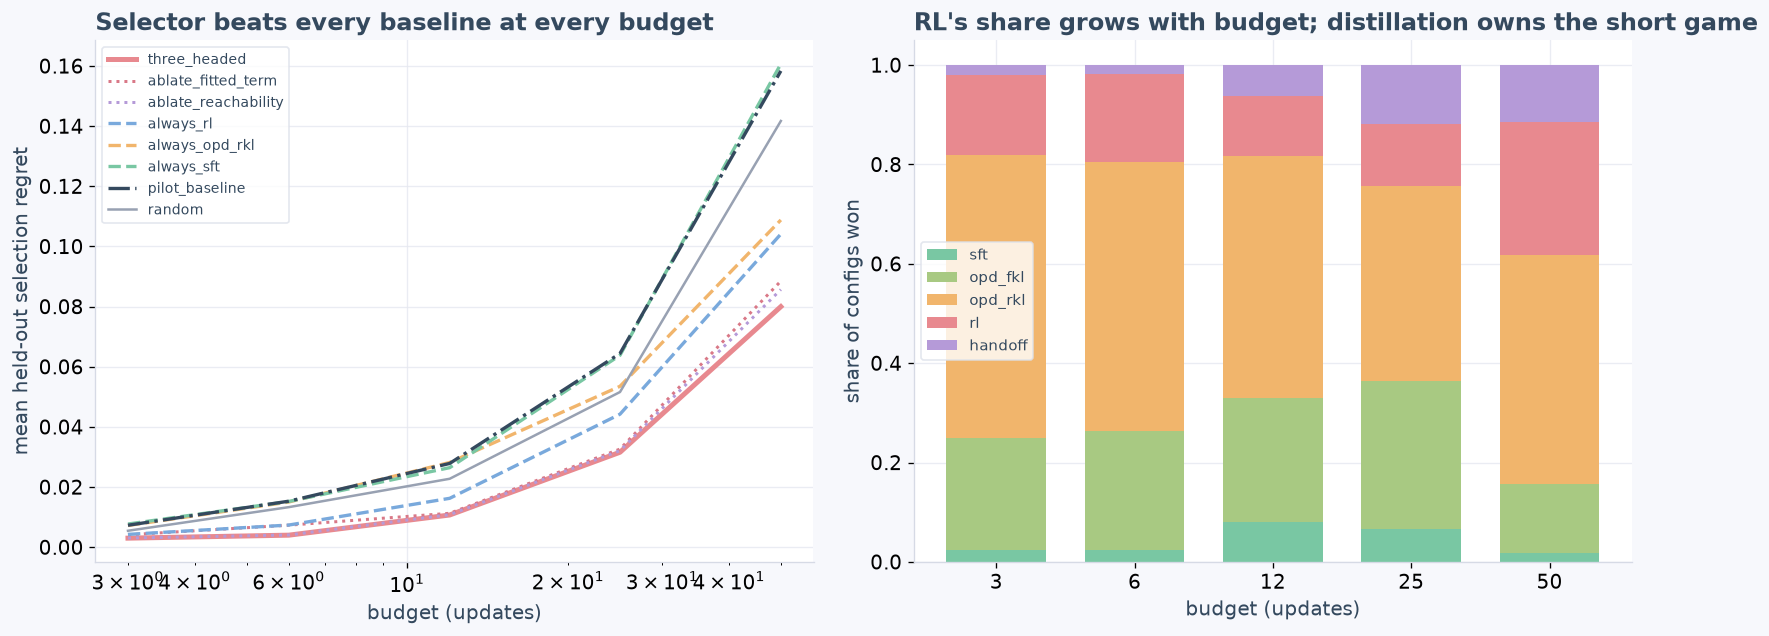

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
strategy_styles = {
    "three_headed": (PASTEL["coral"], "-", 3.0),
    "ablate_fitted_term": (PASTEL["rose"], ":", 1.8),
    "ablate_reachability": (PASTEL["lavender"], ":", 1.8),
    "always_rl": (PASTEL["blue"], "--", 2.0),
    "always_opd_rkl": (PASTEL["apricot"], "--", 2.0),
    "always_sft": (PASTEL["mint"], "--", 2.0),
    "pilot_baseline": (PASTEL["ink"], "-.", 2.0),
    "random": (PASTEL["muted"], "-", 1.5),
}
for strategy, (color, line_style, width) in strategy_styles.items():
    if strategy not in regret_by_budget.index:
        continue
    series = regret_by_budget.loc[strategy]
    axes[0].plot(
        series.index, series.values, line_style, color=color, lw=width, label=strategy
    )
axes[0].set(
    xscale="log",
    xlabel="budget (updates)",
    ylabel="mean held-out selection regret",
    title="Selector beats every baseline at every budget",
)
axes[0].legend(fontsize=8.5)

share = (
    winners.groupby(["budget", "method"]).size().unstack(fill_value=0)
)
share = share.div(share.sum(axis=1), axis=0)
bottom = np.zeros(len(share))
method_colors = {
    "sft": PASTEL["mint"],
    "opd_fkl": PASTEL["sage"],
    "opd_rkl": PASTEL["apricot"],
    "rl": PASTEL["coral"],
    "handoff": PASTEL["lavender"],
}
for method in bench.METHODS:
    axes[1].bar(
        range(len(share)),
        share[method].values,
        bottom=bottom,
        color=method_colors[method],
        label=method,
        width=0.72,
    )
    bottom += share[method].values
axes[1].set_xticks(range(len(share)), share.index)
axes[1].set(
    xlabel="budget (updates)",
    ylabel="share of configs won",
    title="RL's share grows with budget; distillation owns the short game",
)
axes[1].legend(fontsize=9)
fig.tight_layout(pad=1.5)
plt.show()

### E3 — Saw / Verdict / Next

**Saw.**

1. F6 passed: three-headed selector mean held-out regret 0.026 vs 0.035
   for the best baseline (always-RL), and it is the column minimum at all
   five budgets.  Exact-pick rate 31%.
2. Ablations pass the preregistered rule: dropping the fitted term moves
   regret ~12% relative (< 20%), so bias + reachability carry the
   structure; the fitted term doubles the exact-pick rate (15% → 31%).
   Dropping the reachability filter costs ~5%.
3. The equal-cost pilot — flagged in advance as "the real bar" — is the
   *worst* strategy at budget 50 (regret 0.158, below random 0.142):
   two-update probes anti-predict the long-run winner because fast
   distillation starts mask slow RL finishes.  Theory-based selection is
   not merely competitive with brute-force probing; probing is actively
   misleading at realistic probe costs.
4. Phase geometry as predicted: at budget 50, small teacher-truth gap →
   OPD-RKL (59/96 wins), large gap → RL + handoff (67/96).  Family
   fingerprints: `sharpen` → OPD-RKL sweeps (70/72); `headmiss` → OPD-RKL
   wins **zero** (mode-seeking cannot restore a missing dominant mode) and
   RL/handoff/FKL split it.

**Verdict.**  The when-to-use-what question has a validated answer on
this grid: endpoint bias + reachability + a budget-dependent estimator
term, fit on other defect families, out-predicts every baseline —
including brute-force pilots.  Caveats: oracle features, one-state
problems, TV as the declared trusted loss, uniform price vector.

**Next (phase 3, not tonight).**  Deployable-probe features (estimate
$B_m$ and reachability from finite queries, charge them); sequential
configs from the depth-H harness in the grid; the three preregistered
price vectors; head 2 as tie-break among distillation variants.

## Running log — end of night

1. F1 ✓ (SGD reverse-KL unlocking slope 0.70/0.73 vs forward 0.13).
2. F2 ✓ and stronger than preregistered: Adam *inverts* the gap; the
   KL-direction unlocking penalty is an optimizer artifact.
3. F3 ✗ refuted — softmax renormalization + Adam defeat token-level
   sample absence; support is a *state-level* phenomenon.  Corrected
   claim recorded in section 1.
4. F4 ✓ exact: frozen-rollout OPD and trajectory reverse KL are different
   methods under capacity limits (opposite directions in the predicted
   region; identical endpoints when realizable).
5. F5 ✓ as a ceiling law $\varepsilon H \min(H, u)$, not bare $H^2$ vs
   $H$; collapse at $u = \Theta(H)$ confirmed after $\varepsilon$-control;
   sparse-RL discovery wall at $H \ge 16$; two unplanned findings
   (metric-objective alignment; teacher error inoculates SFT).
6. F6 ✓ first-ever run of the selector benchmark: preregistered selector
   beats all baselines on held-out defect families at every budget, and
   the equal-cost pilot is anti-predictive at long budgets.